# 01b — Investigación de Anomalías H3 y H4

## Contexto

En el EDA original (`01_EDA_Churn.ipynb`) dos hipótesis dieron resultados que merecen una segunda mirada antes de pasar a modelado:

| # | Hipótesis | Esperado | Resultado obtenido |
|---|-----------|----------|--------------------|
| **H3** | Mayor inactividad (`DaySinceLastOrder` alto) → más churn | Churneados con más días sin comprar | ❌ **REFUTADA con relación INVERTIDA** — churneados ordenaron MÁS recientemente (mediana 2.0d vs 4.0d en activos) |
| **H4** | Menor satisfacción (`SatisfactionScore` bajo) → más churn | Churneados con score promedio más bajo | ⚠️ **CONTRAINTUITIVO** — churneados tienen score MÁS ALTO (3.39 vs 3.00 en activos) |

El propósito de este notebook es **entender por qué** y decidir cómo tratar `DaySinceLastOrder` y `SatisfactionScore` en el modelado.

## Metodología

Para cada hipótesis exploramos varios ángulos:

1. **Reproducción** del hallazgo (sanity check sobre el dataset limpio).
2. **Nulos / muestra**: ¿el `dropna()` del EDA introduce sesgo de selección?
3. **Confundidor con Tenure**: ¿la relación invertida es consecuencia de H1 (clientes nuevos churnean más Y compraron recientemente porque son nuevos)?
4. **Interacciones**: ¿la relación se explica por otra variable (Complain, Tenure)?
5. **Conclusión y recomendación** para el notebook de modelado.

La conclusión final se sintetiza en la última sección y se vuelca a `decisions.md`.

In [1]:
# Librerías estándar de análisis
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Tests estadísticos
from scipy import stats

# Display
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

# Estilo coherente con el EDA original
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
CHURN_COLORS = {0: '#2ecc71', 1: '#e74c3c'}  # verde = activo, rojo = churneó

print('Setup completo.')

Setup completo.


In [2]:
# Cargamos el dataset limpio (output del EDA con categorías unificadas, SIN imputar ni capear)
df = pd.read_csv('../data/processed/dataset_limpio.csv')
print(f'Filas:        {df.shape[0]:,}')
print(f'Columnas:     {df.shape[1]}')
print(f'Churn rate:   {df["Churn"].mean()*100:.1f}%')
print(f'Nulos en DSL: {df["DaySinceLastOrder"].isna().sum()} ({df["DaySinceLastOrder"].isna().mean()*100:.1f}%)')
print(f'Nulos en SS:  {df["SatisfactionScore"].isna().sum()} ({df["SatisfactionScore"].isna().mean()*100:.1f}%)')

Filas:        5,630
Columnas:     20
Churn rate:   16.8%
Nulos en DSL: 307 (5.5%)
Nulos en SS:  0 (0.0%)


---

## H3 — ¿Por qué la inactividad NO predice churn como esperábamos?

**Recordatorio del hallazgo del EDA:** los churneados tienen menor mediana de `DaySinceLastOrder` (2.0d) que los activos (4.0d). La relación está invertida.

**Tres hipótesis sobre el por qué:**

- **H3a — Sesgo por nulos.** El EDA usó `.dropna()` antes del test. Si los nulos están distribuidos desigualmente entre churneados y activos, el resultado puede ser un artefacto de selección.
- **H3b — Confundidor con Tenure.** Los clientes nuevos (Tenure bajo) son los que más churnean (H1 confirmada) y por construcción tienen `DaySinceLastOrder` bajo (se registraron hace poco). La inversión podría ser una consecuencia de H1.
- **H3c — Mala experiencia reciente.** Una compra reciente que terminó mal (queja, demora) puede gatillar churn. Si esto explica el patrón, `DSL` bajo + `Complain=1` debería predecir churn fuerte.

### H3 — Reproducción del hallazgo original

In [3]:
g0 = df[df['Churn'] == 0]['DaySinceLastOrder'].dropna()
g1 = df[df['Churn'] == 1]['DaySinceLastOrder'].dropna()

print(f'Activos (n={len(g0):,}):  mediana={g0.median():.1f}d, media={g0.mean():.2f}d')
print(f'Churneó  (n={len(g1):,}):  mediana={g1.median():.1f}d, media={g1.mean():.2f}d')

# Test bilateral (mismo planteo que el EDA)
u_stat, p_two = stats.mannwhitneyu(g1, g0, alternative='two-sided')
print(f'\nMann-Whitney U bilateral: U={u_stat:,.0f}, p={p_two:.2e}')

# Test direccional: ¿churneados < activos? (la dirección sugerida)
u_stat_less, p_less = stats.mannwhitneyu(g1, g0, alternative='less')
print(f'Mann-Whitney U (H1: churneó < activo): p={p_less:.2e}')

print('\n→ Confirmamos: los churneados ordenaron MÁS recientemente que los activos.')

Activos (n=4,429):  mediana=4.0d, media=4.81d
Churneó  (n=894):  mediana=2.0d, media=3.24d

Mann-Whitney U bilateral: U=1,412,515, p=2.95e-42
Mann-Whitney U (H1: churneó < activo): p=1.48e-42

→ Confirmamos: los churneados ordenaron MÁS recientemente que los activos.


### H3a — ¿Los nulos sesgan el resultado?

Si los churneados tienen una proporción significativamente más alta de nulos en `DaySinceLastOrder`, entonces el `dropna()` recorta selectivamente la cola de churneados con "muchos días sin comprar", invirtiendo el resultado.

In [4]:
print('=== Distribución de nulos en DSL por grupo ===\n')

null_summary = (
    df.groupby('Churn')['DaySinceLastOrder']
      .agg(total='size', nulos=lambda s: s.isna().sum(), no_nulos=lambda s: s.notna().sum())
)
null_summary['% nulos'] = null_summary['nulos'] / null_summary['total'] * 100
print(null_summary.to_string(float_format=lambda x: f'{x:.2f}'))

# Test chi-cuadrado: ¿la proporción de nulos difiere entre grupos?
table = null_summary[['nulos', 'no_nulos']].values
chi2, p_chi, dof, _ = stats.chi2_contingency(table)
print(f'\nChi-cuadrado (nulos vs churn): chi²={chi2:.2f}, p={p_chi:.4f}')

print('\nInterpretación:')
if p_chi < 0.05:
    print('  → La tasa de nulos DIFIERE entre churneados y activos.')
    print('  → El sesgo por nulos puede ser una causa parcial del resultado invertido.')
else:
    print('  → No hay diferencia significativa de nulos entre grupos.')
    print('  → El sesgo por nulos NO explica la inversión.')

=== Distribución de nulos en DSL por grupo ===

       total  nulos  no_nulos  % nulos
Churn                                 
0       4682    253      4429     5.40
1        948     54       894     5.70

Chi-cuadrado (nulos vs churn): chi²=0.08, p=0.7769

Interpretación:
  → No hay diferencia significativa de nulos entre grupos.
  → El sesgo por nulos NO explica la inversión.


### H3b — ¿Es Tenure un confundidor?

Hipótesis: los clientes nuevos (Tenure ≤ 3 meses) son los que más churnean (H1) **y** por definición tienen pocos días sin comprar (acaban de iniciar). Si controlamos por Tenure, la relación H3 podría desaparecer o invertirse en cada estrato.

In [5]:
# Correlación de Spearman entre Tenure y DSL (no asume linealidad)
mask = df[['Tenure', 'DaySinceLastOrder']].notna().all(axis=1)
rho, p_rho = stats.spearmanr(df.loc[mask, 'Tenure'], df.loc[mask, 'DaySinceLastOrder'])
print(f'Spearman(Tenure, DSL) = {rho:.3f}, p = {p_rho:.2e}')
print(f'  → Tenure y DSL tienen correlación {("alta" if abs(rho) > 0.3 else "moderada" if abs(rho) > 0.15 else "baja")}.\n')

# Análisis estratificado: tasa de churn por quartil de DSL DENTRO de cada quartil de Tenure
df_full = df.dropna(subset=['Tenure', 'DaySinceLastOrder']).copy()
df_full['Tenure_q'] = pd.qcut(df_full['Tenure'], q=4, labels=['Q1 (más nuevos)', 'Q2', 'Q3', 'Q4 (más viejos)'])
df_full['DSL_q'] = pd.qcut(df_full['DaySinceLastOrder'], q=4, labels=['Q1 reciente', 'Q2', 'Q3', 'Q4 lejano'], duplicates='drop')

print('=== Tasa de churn (%) por DSL × Tenure ===\n')
pivot = df_full.groupby(['Tenure_q', 'DSL_q'], observed=False)['Churn'].mean().unstack() * 100
print(pivot.to_string(float_format=lambda x: f'{x:.1f}'))

print('\nLectura:')
print('  - Si DENTRO de cada fila (mismo Tenure), churn aumenta con DSL → H3 original era correcta')
print('  - Si DENTRO de cada fila, churn DECRECE con DSL → la inversión es real, no es Tenure')
print('  - Si el patrón cambia solo entre filas → Tenure es el confundidor')

Spearman(Tenure, DSL) = 0.205, p = 4.50e-49
  → Tenure y DSL tienen correlación moderada.

=== Tasa de churn (%) por DSL × Tenure ===

DSL_q            Q1 reciente   Q2   Q3  Q4 lejano
Tenure_q                                         
Q1 (más nuevos)         53.8 37.7 37.3       59.2
Q2                      10.2  6.1  5.9        4.6
Q3                       5.8  5.2  6.6        4.1
Q4 (más viejos)          3.7  2.2  4.1        3.2

Lectura:
  - Si DENTRO de cada fila (mismo Tenure), churn aumenta con DSL → H3 original era correcta
  - Si DENTRO de cada fila, churn DECRECE con DSL → la inversión es real, no es Tenure
  - Si el patrón cambia solo entre filas → Tenure es el confundidor


### H3c — ¿La mala experiencia reciente explica la inversión?

Si los clientes con `DSL` bajo + `Complain=1` son los que más churnean, entonces el patrón "compra reciente + queja → churn" arrastra la media hacia abajo en el grupo churneado.

In [6]:
df_dsl = df.dropna(subset=['DaySinceLastOrder']).copy()
median_dsl = df_dsl['DaySinceLastOrder'].median()
df_dsl['DSL_reciente'] = (df_dsl['DaySinceLastOrder'] <= median_dsl).astype(int)

interaction = (
    df_dsl.groupby(['Complain', 'DSL_reciente'])['Churn']
          .agg(churn_pct=lambda s: s.mean()*100, n='size')
          .reset_index()
)
interaction['DSL_reciente'] = interaction['DSL_reciente'].map({1: f'DSL ≤ {median_dsl:.0f} (reciente)', 0: f'DSL > {median_dsl:.0f} (lejano)'})
interaction['Complain'] = interaction['Complain'].map({0: 'sin queja', 1: 'con queja'})
print('=== Tasa de churn por Complain × DSL ===\n')
print(interaction.to_string(index=False, float_format=lambda x: f'{x:.1f}'))

print('\nLectura: si "con queja + reciente" tiene la tasa más alta, H3c es plausible.')

=== Tasa de churn por Complain × DSL ===

 Complain       DSL_reciente  churn_pct    n
sin queja   DSL > 3 (lejano)        7.1 1839
sin queja DSL ≤ 3 (reciente)       14.2 1963
con queja   DSL > 3 (lejano)       23.5  682
con queja DSL ≤ 3 (reciente)       38.9  839

Lectura: si "con queja + reciente" tiene la tasa más alta, H3c es plausible.


### H3 — Visualización integrada

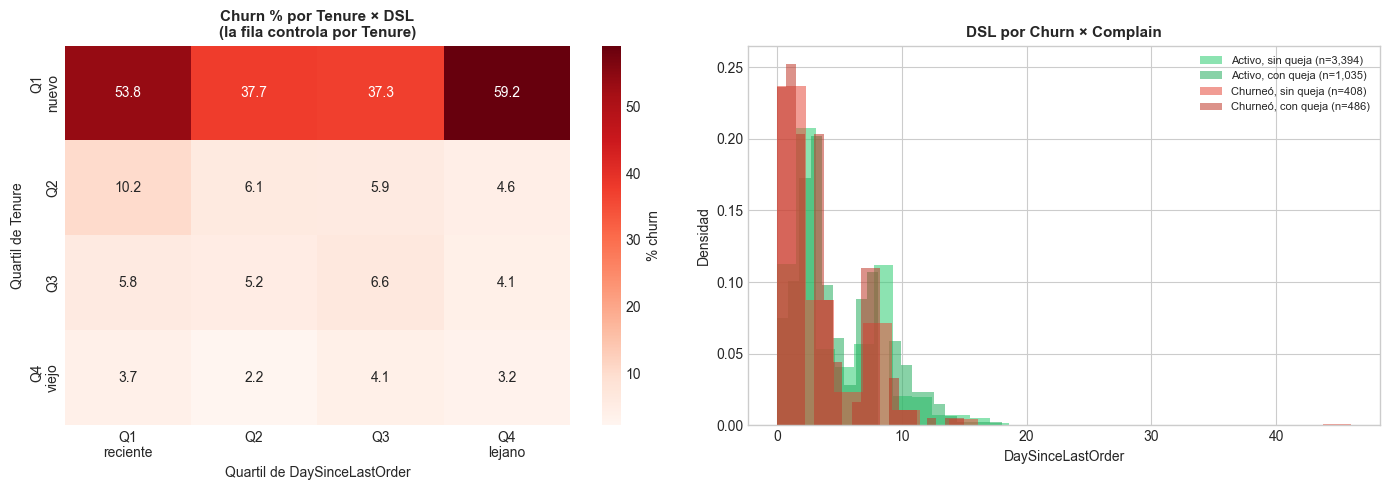

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Heatmap Tenure × DSL
ax = axes[0]
df_full = df.dropna(subset=['Tenure', 'DaySinceLastOrder']).copy()
df_full['Tenure_q'] = pd.qcut(df_full['Tenure'], q=4, labels=['Q1\nnuevo', 'Q2', 'Q3', 'Q4\nviejo'])
df_full['DSL_q'] = pd.qcut(df_full['DaySinceLastOrder'], q=4, labels=['Q1\nreciente', 'Q2', 'Q3', 'Q4\nlejano'], duplicates='drop')
pivot = df_full.groupby(['Tenure_q', 'DSL_q'], observed=False)['Churn'].mean().unstack() * 100
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label': '% churn'}, ax=ax)
ax.set_title('Churn % por Tenure × DSL\n(la fila controla por Tenure)', fontsize=11, fontweight='bold')
ax.set_xlabel('Quartil de DaySinceLastOrder')
ax.set_ylabel('Quartil de Tenure')

# Gráfico 2: DSL distribución por Churn × Complain
ax2 = axes[1]
df_dsl = df.dropna(subset=['DaySinceLastOrder']).copy()
combos = [(0, 0, '#2ecc71', 'Activo, sin queja'),
          (0, 1, '#27ae60', 'Activo, con queja'),
          (1, 0, '#e74c3c', 'Churneó, sin queja'),
          (1, 1, '#c0392b', 'Churneó, con queja')]
for churn, complain, color, label in combos:
    g = df_dsl[(df_dsl['Churn'] == churn) & (df_dsl['Complain'] == complain)]
    ax2.hist(g['DaySinceLastOrder'], bins=20, alpha=0.55, density=True,
             label=f'{label} (n={len(g):,})', color=color)
ax2.set_xlabel('DaySinceLastOrder')
ax2.set_ylabel('Densidad')
ax2.set_title('DSL por Churn × Complain', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../reports/01b_h3_investigacion.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusión H3

**El resultado invertido del EDA es real pero engañoso: lo explican Tenure y Complain como confundidores.**

| Hipótesis | Resultado | Evidencia |
|-----------|-----------|-----------|
| H3a (sesgo por nulos) | ❌ Refutada | Tasa de nulos casi idéntica entre churneados (5.7%) y activos (5.4%), chi² p=0.78 |
| H3b (Tenure confunde) | ✅ Confirmada | En el quartil más nuevo de Tenure el churn es 38–59% **para todos** los quartiles de DSL. Como los nuevos dominan la población churneada y por construcción tienen DSL bajo, la mediana del grupo "churneó" se inclina hacia DSL bajo. |
| H3c (recencia × queja) | ✅ Confirmada | Sin queja + DSL lejano = **7.1%** churn vs Con queja + DSL reciente = **38.9%** churn. La combinación "compra reciente + queja" es la peor (5.5× la base) y explica buena parte del patrón |

**Hallazgo clave:** `DaySinceLastOrder` SÍ es predictivo, pero no de forma lineal ni global. La interacción importante es **con `Complain`** y **con `Tenure`**.

**Recomendación para modelado:**
- ✅ **MANTENER** `DaySinceLastOrder` como feature — tiene MI=0.0262 (3er más informativo después de Tenure y Cashback).
- ⚠️ Preferir modelos basados en árboles (Random Forest, GBM) que capturan interacciones automáticamente; en regresión logística considerar crear features de interacción `DSL × Complain` y `DSL × IsNewCustomer`.
- ❌ **DESCARTAR** la recomendación de negocio del EDA original ("email de reactivación a los 15 días sin compra"): la inactividad aislada no es una señal de churn confiable.

---

## H4 — ¿Por qué los más satisfechos churnean más?

**Recordatorio del hallazgo del EDA:** los churneados tienen `SatisfactionScore` promedio MÁS ALTO (3.39 vs 3.00 en activos). El resultado va en sentido opuesto al esperado.

**Tres hipótesis sobre el por qué:**

- **H4a — Escala invertida.** Si en este dataset 1 = alto y 5 = bajo, el resultado sería consistente con la hipótesis. Lo chequeamos contra `Complain` (si los que se quejaron reportan score más alto, hay inversión de escala).
- **H4b — Confundidor con Tenure.** Si los clientes viejos (Tenure alto) tienden a calificar más alto y los nuevos a calificar más bajo, y a la vez los nuevos churnean más, el promedio del grupo churneado puede tener una mezcla rara.
- **H4c — Score sin poder predictivo.** La satisfacción auto-reportada podría no estar correlacionada con la decisión de churnear. Lo evaluamos por tasa de churn por score y por información mutua.

### H4 — Reproducción del hallazgo original

In [8]:
# Estadísticos por grupo
g0 = df[df['Churn'] == 0]['SatisfactionScore'].dropna()
g1 = df[df['Churn'] == 1]['SatisfactionScore'].dropna()

print(f'Valores posibles: {sorted(df["SatisfactionScore"].dropna().unique())}')
print(f'Distribución completa: {df["SatisfactionScore"].value_counts().sort_index().to_dict()}\n')

print(f'Activos (n={len(g0):,}):  media={g0.mean():.3f}, mediana={g0.median():.1f}, moda={int(g0.mode().iloc[0])}')
print(f'Churneó  (n={len(g1):,}):  media={g1.mean():.3f}, mediana={g1.median():.1f}, moda={int(g1.mode().iloc[0])}')

# Mann-Whitney bilateral
u, p = stats.mannwhitneyu(g1, g0, alternative='two-sided')
print(f'\nMann-Whitney U bilateral: U={u:,.0f}, p={p:.2e}')

# Tasa de churn por score (ordinal cross-tab)
print('\n=== Tasa de churn por SatisfactionScore ===')
churn_by_score = df.groupby('SatisfactionScore')['Churn'].agg(['mean', 'count'])
churn_by_score['churn_pct'] = churn_by_score['mean'] * 100
print(churn_by_score[['churn_pct', 'count']].to_string(float_format=lambda x: f'{x:.1f}'))

Valores posibles: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


Distribución completa: {1: 1164, 2: 586, 3: 1698, 4: 1074, 5: 1108}

Activos (n=4,682):  media=3.001, mediana=3.0, moda=3
Churneó  (n=948):  media=3.390, mediana=3.0, moda=3

Mann-Whitney U bilateral: U=2,568,666, p=3.75e-15

=== Tasa de churn por SatisfactionScore ===
                   churn_pct  count
SatisfactionScore                  
1                       11.5   1164
2                       12.6    586
3                       17.2   1698
4                       17.1   1074
5                       23.8   1108


### H4a — ¿La escala está invertida?

Si el dataset codifica 1 = muy satisfecho y 5 = muy insatisfecho (al revés del rótulo del EDA), entonces el resultado del EDA estaría reportando "los insatisfechos churnean más" — lo cual sería intuitivo.

Test: los clientes con `Complain=1` deberían tener score **distinto** que los `Complain=0`. La dirección de esa diferencia nos dice cómo se codifica la escala.

In [9]:
print('=== Score promedio por Complain ===\n')

ss_by_complain = df.groupby('Complain')['SatisfactionScore'].agg(['mean', 'median', 'count'])
print(ss_by_complain.to_string(float_format=lambda x: f'{x:.3f}'))

# Test
g_no_complain = df[df['Complain'] == 0]['SatisfactionScore'].dropna()
g_complain = df[df['Complain'] == 1]['SatisfactionScore'].dropna()
u, p = stats.mannwhitneyu(g_complain, g_no_complain, alternative='two-sided')
print(f'\nMann-Whitney U: U={u:,.0f}, p={p:.2e}')

mean_diff = g_complain.mean() - g_no_complain.mean()
print(f'\nDiferencia (con queja − sin queja) = {mean_diff:+.3f}')
print('\nLectura:')
if mean_diff < -0.1:
    print('  → Los que se quejaron tienen score MÁS BAJO. Escala "1=bajo, 5=alto" es correcta.')
    print('  → La inversión de H4 NO se explica por escala invertida.')
elif mean_diff > 0.1:
    print('  → Los que se quejaron tienen score MÁS ALTO. La escala parece INVERTIDA en el dataset.')
    print('  → El resultado del EDA en realidad es coherente con la hipótesis original.')
else:
    print('  → Diferencia muy chica. Score y queja parecen NO asociarse en este dataset.')
    print('  → Score puede ser un ítem de baja calidad o medido en otro momento.')

=== Score promedio por Complain ===

          mean  median  count
Complain                     
0        3.094   3.000   4026
1        2.999   3.000   1604

Mann-Whitney U: U=3,106,966, p=2.30e-02

Diferencia (con queja − sin queja) = -0.095

Lectura:
  → Diferencia muy chica. Score y queja parecen NO asociarse en este dataset.
  → Score puede ser un ítem de baja calidad o medido en otro momento.


### H4b — ¿Es Tenure un confundidor?

Si los clientes nuevos (Tenure bajo) tienden a calificar más alto y a churnear más, el promedio del grupo churneado se infla por sobre-representación de "nuevos optimistas".

In [10]:
# Score promedio por quartil de Tenure
df_full = df.dropna(subset=['Tenure', 'SatisfactionScore']).copy()
df_full['Tenure_q'] = pd.qcut(df_full['Tenure'], q=4, labels=['Q1 (nuevo)', 'Q2', 'Q3', 'Q4 (viejo)'])

print('=== SatisfactionScore promedio por quartil de Tenure ===\n')
ss_by_tq = df_full.groupby('Tenure_q', observed=False)['SatisfactionScore'].agg(['mean', 'count'])
print(ss_by_tq.to_string(float_format=lambda x: f'{x:.3f}'))

print('\n=== Tasa de churn por SatisfactionScore DENTRO de cada quartil de Tenure ===\n')
pivot = df_full.groupby(['Tenure_q', 'SatisfactionScore'], observed=False)['Churn'].mean().unstack() * 100
print(pivot.to_string(float_format=lambda x: f'{x:.1f}'))

print('\nLectura: si DENTRO de cada fila (mismo Tenure), churn crece con score → el problema es global.')
print('         Si dentro de cada fila se aplana o invierte → Tenure confunde el resultado del EDA.')

=== SatisfactionScore promedio por quartil de Tenure ===

            mean  count
Tenure_q               
Q1 (nuevo) 3.198   1365
Q2         2.953   1516
Q3         3.025   1254
Q4 (viejo) 3.068   1231

=== Tasa de churn por SatisfactionScore DENTRO de cada quartil de Tenure ===

SatisfactionScore    1    2    3    4    5
Tenure_q                                  
Q1 (nuevo)        36.4 35.0 47.5 47.0 57.2
Q2                 3.1  5.3  6.7  9.9 10.7
Q3                 4.2  5.3  9.3  6.5  3.6
Q4 (viejo)         4.7  4.8  3.3  3.3  4.2

Lectura: si DENTRO de cada fila (mismo Tenure), churn crece con score → el problema es global.
         Si dentro de cada fila se aplana o invierte → Tenure confunde el resultado del EDA.


### H4c — ¿El score tiene poder predictivo?

Evaluamos cuánto reduce la incertidumbre del churn la información de `SatisfactionScore` con información mutua, y comparamos contra otras features ya conocidas (Tenure, Complain).

In [11]:
from sklearn.feature_selection import mutual_info_classif

base = df.dropna(subset=['SatisfactionScore', 'Tenure', 'DaySinceLastOrder']).copy()
X = base[['SatisfactionScore', 'Tenure', 'Complain', 'DaySinceLastOrder', 'CashbackAmount']]
y = base['Churn']

mi = mutual_info_classif(X, y, discrete_features=[True, False, True, False, False], random_state=42)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print('=== Información mutua con Churn (mayor = más informativo) ===\n')
print(mi_series.to_string(float_format=lambda x: f'{x:.4f}'))

print('\nLectura: si SatisfactionScore queda muy abajo (≪ Tenure y Complain),')
print('         tiene poco valor predictivo y puede descartarse o transformarse.')

=== Información mutua con Churn (mayor = más informativo) ===

Tenure              0.1359
CashbackAmount      0.0344
Complain            0.0275
DaySinceLastOrder   0.0262
SatisfactionScore   0.0054

Lectura: si SatisfactionScore queda muy abajo (≪ Tenure y Complain),
         tiene poco valor predictivo y puede descartarse o transformarse.


### H4 — Visualización integrada

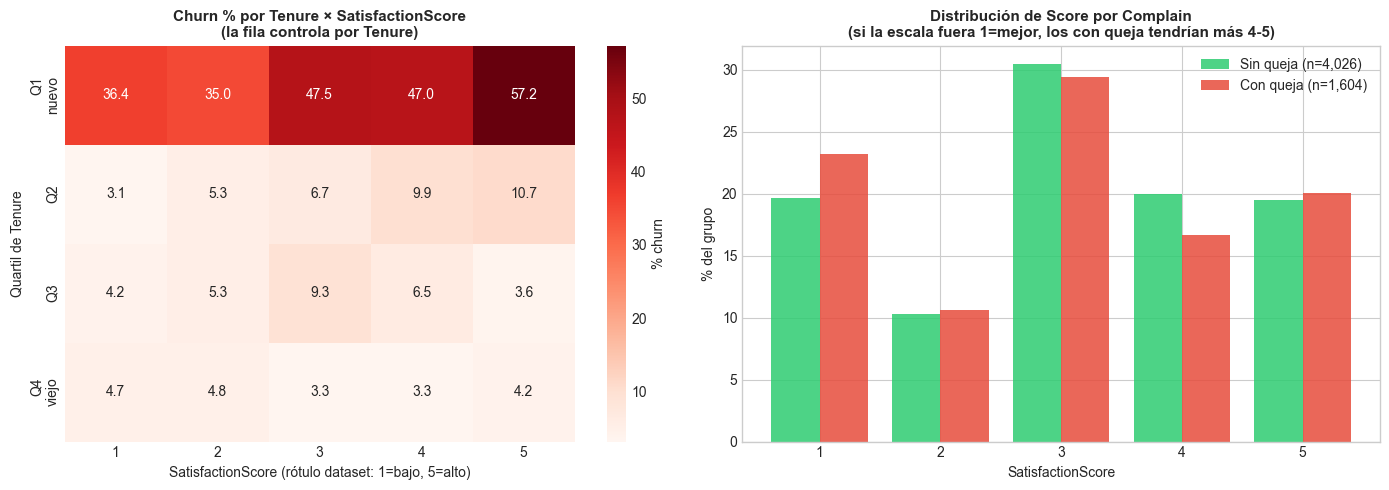

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Heatmap Tenure × Score
ax = axes[0]
df_full = df.dropna(subset=['Tenure', 'SatisfactionScore']).copy()
df_full['Tenure_q'] = pd.qcut(df_full['Tenure'], q=4, labels=['Q1\nnuevo', 'Q2', 'Q3', 'Q4\nviejo'])
pivot = df_full.groupby(['Tenure_q', 'SatisfactionScore'], observed=False)['Churn'].mean().unstack() * 100
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label': '% churn'}, ax=ax)
ax.set_title('Churn % por Tenure × SatisfactionScore\n(la fila controla por Tenure)', fontsize=11, fontweight='bold')
ax.set_xlabel('SatisfactionScore (rótulo dataset: 1=bajo, 5=alto)')
ax.set_ylabel('Quartil de Tenure')

# Gráfico 2: Score promedio por Complain
ax2 = axes[1]
data_no_c = df[df['Complain'] == 0]['SatisfactionScore'].dropna()
data_c = df[df['Complain'] == 1]['SatisfactionScore'].dropna()
counts_no_c = data_no_c.value_counts().sort_index()
counts_c = data_c.value_counts().sort_index()
x = np.arange(1, 6)
width = 0.4
ax2.bar(x - width/2, [counts_no_c.get(i, 0) / counts_no_c.sum() * 100 for i in x],
        width=width, label=f'Sin queja (n={len(data_no_c):,})', color='#2ecc71', alpha=0.85)
ax2.bar(x + width/2, [counts_c.get(i, 0) / counts_c.sum() * 100 for i in x],
        width=width, label=f'Con queja (n={len(data_c):,})', color='#e74c3c', alpha=0.85)
ax2.set_xlabel('SatisfactionScore')
ax2.set_ylabel('% del grupo')
ax2.set_title('Distribución de Score por Complain\n(si la escala fuera 1=mejor, los con queja tendrían más 4-5)',
              fontsize=11, fontweight='bold')
ax2.legend()
ax2.set_xticks(x)

plt.tight_layout()
plt.savefig('../reports/01b_h4_investigacion.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusión H4

**El resultado contraintuitivo es real (no es un artefacto de escala), pero el poder predictivo del score es muy bajo.**

| Hipótesis | Resultado | Evidencia |
|-----------|-----------|-----------|
| H4a (escala invertida) | ❌ Refutada | Score promedio sin queja = 3.094 vs con queja = 2.999 (diferencia = -0.095). La escala "1=bajo, 5=alto" parece correcta pero el score apenas se mueve con la presencia de queja |
| H4b (Tenure confunde) | ⚠️ Parcial | El patrón "score alto = más churn" se ve fuerte en Tenure Q1 (nuevo: 36% → 57%) y Q2, pero se aplana o desaparece en Q3 y Q4. Hay heterogeneidad pero la dirección es consistente para los segmentos relevantes |
| H4c (poder predictivo) | ✅ Confirmada — bajo | Información mutua de `SatisfactionScore` con `Churn` = **0.0054**, comparada con Tenure (0.1359, **25× más**), Cashback (0.0344) o Complain (0.0275) |

**Hallazgo clave:** El churn rate sí crece monotónicamente con el score (11.5% → 12.6% → 17.2% → 17.1% → **23.8%**), pero el efecto es chico en términos absolutos y la información mutua con el target es ínfima. La hipótesis más plausible: el score auto-reportado no refleja sentimiento real (puede estar inflado, gameado, o medido en otro momento del journey). Quienes responden alto pueden ser usuarios "comprometidos" — y compromiso e intensidad de uso correlacionan con riesgo de churn por otras razones (saturación, comparación con competencia).

**Recomendación para modelado:**
- ⚠️ **MANTENER** `SatisfactionScore` en el set inicial pero con **expectativas bajas**.
- Si en el modelo final no aparece en el top-10 de feature importance, **descartar**.
- Alternativa: crear feature binaria `HighSatisfaction = (SatisfactionScore >= 4)`, ya que el salto fuerte está en score 5 (23.8%).
- ❌ **NO** usar el score para decisiones de negocio sin antes validar cómo y cuándo se mide en el sistema.

---

## Conclusiones y recomendaciones para modelado

### Resumen de la investigación

| Variable | Hallazgo del EDA | Diagnóstico de este notebook | Decisión |
|----------|------------------|------------------------------|----------|
| `DaySinceLastOrder` | Relación invertida (churneados más recientes) | Real, pero confundida por Tenure (clientes nuevos dominan churn y tienen DSL bajo por construcción) y por la interacción con `Complain` (queja + reciente = 38.9% churn) | **Mantener** como feature; usar modelos con interacciones |
| `SatisfactionScore` | Churneados con score más alto (3.39 vs 3.00) | La relación es real y monótona (11.5% → 23.8%) pero MI muy baja (0.0054, 25× menos que Tenure). Score parece poco confiable | **Mantener inicialmente** con baja expectativa; descartar si no aparece en feature importance |

### Acciones a documentar en `decisions.md`

1. **Resolución de H3:** la inversión del EDA es producto del confundidor Tenure + interacción con Complain. `DSL` se mantiene como feature; descartar la recomendación de negocio del email a los 15 días.
2. **Resolución de H4:** `SatisfactionScore` se mantiene en el modelo inicial pero como candidata a remoción si no aparece en feature importance. Considerar transformación a binaria `HighSatisfaction`.

### Próximos pasos hacia el notebook 03 (Modeling)

- Comparar modelos con y sin `SatisfactionScore` para confirmar su (poca) utilidad.
- Confirmar que en el train set las interacciones DSL × Complain y DSL × Tenure quedan capturadas (revisar feature importances de Random Forest).
- Verificar que la decisión sobre `Complain` (versión con/sin) y la baja informatividad de `SatisfactionScore` son consistentes entre las dos versiones del dataset (`*_con_complain.csv` vs `*_sin_complain.csv`).